# Loan Default Risk Analysis — Exploratory Data Analysis
## Portfolio Project | Simulated 2024–2025 Loan Portfolio

> **Note:** This is an independent portfolio project using simulated loan data.
> The business scenario is fictional, but the methodology — segment analysis,
> statistical testing, interaction heatmaps, policy simulation, and baseline
> modeling — reflects a real-world credit risk workflow.

---

### Executive Summary

A simulated personal loan portfolio is defaulting at **24.3%** — more than double the
**12% target**. This analysis examines 601 loans issued to 500 borrowers across 2024–2025
to identify which borrower characteristics and loan attributes drive default risk, and to
recommend actionable underwriting policy changes.

**Key Findings:**
- **Credit score is the strongest predictor** — borrowers scoring 520–599 default at 49.1% (4× the target)
- **DTI ratio compounds risk** — DTI above 50% pushes default rates to 36%; combined with low credit scores, defaults reach 60%
- **Employment tenure < 2 years** is a statistically significant risk factor (35.1% vs 22.7%, p = 0.038)
- **Loan amount does NOT predict default** (p = 0.657) — the problem is borrower quality, not loan size
- If the 103 currently "Late" loans convert to default, the portfolio rate jumps to **41.4%**

**Recommendation:** A credit score floor of 620 combined with a DTI cap of 55% brings the default rate
to ~12.3% (essentially at target) while rejecting ~50% of the current book — the best trade-off point
identified in the graduated policy simulation.

---

### Table of Contents

| Step | Section | Description |
|------|---------|-------------|
| 1 | [Data Loading & Exploration](#step1) | Load, inspect, identify quality issues |
| 2 | [Cleaning Plan](#step2) | Document decisions before applying changes |
| 3 | [Data Preparation](#step3) | Clean, flag, merge datasets |
| 4 | [Feature Engineering](#step4) | Create analytical segments |
| 5 | [Segment Analysis](#step5) | Default rates across all segments |
| 6 | [Exploratory Analysis](#step6) | Continuous variables, correlations, interactions |
| 7 | [Statistical Testing](#step7) | t-tests, chi-square — what's significant? |
| 8 | [Visualizations](#step8) | Publication-quality charts |
| 9 | [Sensitivity Analysis](#step9) | What if Late loans default? |
| 10 | [Business Insights](#step10) | Key findings summary |
| 11 | [Policy Simulation](#step11) | Graduated threshold trade-off analysis |
| 12 | [Expected Loss](#step12) | Dollar-value loss exposure |
| 13 | [Baseline Modeling](#step13) | Preliminary LR & RF with improvements |
| 14 | [Conclusion](#step14) | Summary, limitations, next steps |

---

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn<br>
**Author:** Pranav

In [ ]:
# ── Setup (single import cell) ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# ── Chart style ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
COLOR_DEFAULT = '#d62728'     # red — above target
COLOR_SAFE    = '#1f77b4'     # blue — at or below target
TARGET_CLR    = '#555555'     # gray dashed line
TARGET_RATE   = 0.12          # 12% default target (scenario threshold)

print("✓ Setup complete")

✓ Setup complete


<a id="step1"></a>
# Step 1 — Data Loading & Initial Exploration

Load both CSV files and inspect structure, types, distributions, and data quality.

In [ ]:
# ── 1.1 Load datasets ────────────────────────────────────────────────
borrowers = pd.read_csv('../data/borrower_profiles.csv')
loans = pd.read_csv('../data/loan_applications.csv')

print(f"Borrower Profiles:  {borrowers.shape[0]} rows × {borrowers.shape[1]} columns")
print(f"Loan Applications:  {loans.shape[0]} rows × {loans.shape[1]} columns")

Borrower Profiles:  500 rows × 11 columns
Loan Applications:  601 rows × 12 columns


In [4]:
# ── 1.2 Borrower profiles — structure ────────────────────────────────
print("Data Types:")
print(borrowers.dtypes.to_string())
print(f"\nFirst 5 Rows:")
borrowers.head()

Data Types:
borrower_id              object
age                       int64
state                    object
education_level          object
employment_status        object
years_employed            int64
annual_income             int64
credit_score              int64
home_ownership           object
dependents                int64
existing_monthly_debt     int64

First 5 Rows:


,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [5]:
# ── 1.3 Borrower profiles — numeric summary ─────────────────────────
borrowers.describe().round(2)

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,44.99,10.85,64471.48,704.95,1.36,1585.17
std,13.54,9.30,28959.84,97.34,1.25,1089.98
min,22.00,0.00,12549.00,528.00,0.00,124.00
25%,33.00,3.00,42968.25,617.75,0.00,788.75
50%,45.00,8.00,59282.50,708.00,1.00,1312.00
75%,57.00,17.00,79780.50,794.25,2.00,2131.75
max,68.00,35.00,157047.00,850.00,4.00,6130.00


In [6]:
# ── 1.4 Borrower profiles — categorical summary ─────────────────────
borrowers.describe(include='object')

,borrower_id,state,education_level,employment_status,home_ownership
count,500,500,500,500,500
unique,500,30,5,5,3
top,BRW-0001,NC,Bachelor,Full-Time,Mortgage
freq,1,25,190,252,216


In [7]:
# ── 1.5 Missing values check — both datasets ────────────────────────
print("Borrower Profiles — Missing Values:")
print(borrowers.isnull().sum().to_string())
print(f"\nLoan Applications — Missing Values:")
print(loans.isnull().sum().to_string())

Borrower Profiles — Missing Values:
borrower_id              0
age                      0
state                    0
education_level          0
employment_status        0
years_employed           0
annual_income            0
credit_score             0
home_ownership           0
dependents               0
existing_monthly_debt    0

Loan Applications — Missing Values:
loan_id             0
borrower_id         0
application_date    0
loan_purpose        0
loan_amount         0
term_months         0
interest_rate       0
monthly_payment     0
dti_ratio           0
loan_status         0
days_delinquent     0
defaulted           0


In [8]:
# ── 1.6 Loan applications — structure ────────────────────────────────
print("Data Types:")
print(loans.dtypes.to_string())
print(f"\nFirst 5 Rows:")
loans.head()

Data Types:
loan_id              object
borrower_id          object
application_date     object
loan_purpose         object
loan_amount         float64
term_months           int64
interest_rate       float64
monthly_payment     float64
dti_ratio           float64
loan_status          object
days_delinquent       int64
defaulted             int64

First 5 Rows:


,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [9]:
# ── 1.7 Loan applications — numeric summary ─────────────────────────
loans.describe().round(2)

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
count,601.00,601.00,601.00,601.00,601.00,601.00,601.00
mean,22148.25,36.54,10.64,948.34,49.68,27.04,0.24
std,13215.26,16.90,2.25,864.96,24.11,47.80,0.43
min,2000.00,12.00,5.86,44.14,7.60,0.00,0.00
25%,10900.00,24.00,8.94,359.86,32.20,0.00,0.00
50%,20400.00,36.00,10.54,684.87,48.10,0.00,0.00
75%,32700.00,48.00,12.33,1165.20,62.40,30.00,0.00
max,49800.00,60.00,15.86,4262.69,177.40,180.00,1.00


In [10]:
# ── 1.8 Loan applications — categorical distributions ────────────────
for col in ['loan_purpose', 'loan_status']:
    print(f"\n{col} ({loans[col].nunique()} unique):")
    print(loans[col].value_counts().to_string())


loan_purpose (10 unique):
loan_purpose
Home Improvement      70
Major Purchase        68
Medical Expenses      68
Vacation              62
Auto Loan             59
Business Loan         58
Wedding               56
Moving                56
Education             53
Debt Consolidation    51

loan_status (4 unique):
loan_status
Current     239
Default     146
Paid Off    113
Late        103


In [11]:
# ── 1.9 Cross-dataset integrity checks ───────────────────────────────
n_borrowers_profiles = borrowers['borrower_id'].nunique()
n_borrowers_loans = loans['borrower_id'].nunique()

orphan_loans = set(loans['borrower_id']) - set(borrowers['borrower_id'])
orphan_borrowers = set(borrowers['borrower_id']) - set(loans['borrower_id'])

default_rate = loans['defaulted'].mean() * 100

print(f"Unique borrowers in profiles:  {n_borrowers_profiles}")
print(f"Unique borrowers in loans:     {n_borrowers_loans}")
print(f"Total loan records:            {len(loans)}")
print(f"Borrowers with multiple loans: {len(loans) - n_borrowers_loans}")
print(f"\nOrphan loans (no matching borrower): {len(orphan_loans)}")
print(f"Orphan borrowers (no loan record):   {len(orphan_borrowers)}")
print(f"\nOverall default rate: {default_rate:.1f}% ({loans['defaulted'].sum()} / {len(loans)})")
print(f"Company target:       12.0%")
print(f"Gap:                  +{default_rate - 12:.1f} percentage points above target")

Unique borrowers in profiles:  500
Unique borrowers in loans:     500
Total loan records:            601
Borrowers with multiple loans: 101

Orphan loans (no matching borrower): 0
Orphan borrowers (no loan record):   0

Overall default rate: 24.3% (146 / 601)
Company target:       12.0%
Gap:                  +12.3 percentage points above target


In [12]:
# ── 1.10 Value range checks ──────────────────────────────────────────
print("--- Value Range Summary ---")
print(f"Credit score:   {borrowers['credit_score'].min()} – {borrowers['credit_score'].max()}")
print(f"Annual income:  ${borrowers['annual_income'].min():,.0f} – ${borrowers['annual_income'].max():,.0f}")
print(f"DTI ratio:      {loans['dti_ratio'].min():.1f}% – {loans['dti_ratio'].max():.1f}%")
print(f"Loan amount:    ${loans['loan_amount'].min():,.0f} – ${loans['loan_amount'].max():,.0f}")
print(f"Interest rate:  {loans['interest_rate'].min():.2f}% – {loans['interest_rate'].max():.2f}%")

# DTI outliers
extreme_dti = loans[loans['dti_ratio'] > 100]
print(f"\nDTI OUTLIERS: {len(extreme_dti)} loans have DTI > 100% (max = {loans['dti_ratio'].max():.1f}%)")
print("→ Borrowers whose debt payments exceed income — flag for investigation")

--- Value Range Summary ---
Credit score:   528 – 850
Annual income:  $12,549 – $157,047
DTI ratio:      7.6% – 177.4%
Loan amount:    $2,000 – $49,800
Interest rate:  5.86% – 15.86%

DTI OUTLIERS: 22 loans have DTI > 100% (max = 177.4%)
→ Borrowers whose debt payments exceed income — flag for investigation


### Data Quality Observations

1. **No missing values** in either dataset — no imputation needed
2. **22 DTI outliers** above 100% — extreme but plausible for high-risk segment; flag but keep
3. **`application_date` is string** — needs datetime conversion
4. **103 "Late" loans** — ambiguous status; could eventually default or recover
5. **101 borrowers have multiple loans** — same demographics appear in multiple rows after merge
6. **`years_employed = 0` for Retired borrowers** — must separate in tenure grouping to avoid distortion

<a id="step2"></a>
# Step 2 — Data Cleaning Plan

| Issue | Decision | Rationale |
|-------|----------|-----------|
| Late loans (103) | Create `risk_flag`: Default / Late / Non-Default. Primary analysis treats Late as non-default. Sensitivity check treats Late as default. | Gives analytical flexibility without discarding data |
| DTI > 100% (22) | Flag with `dti_extreme` boolean; keep in dataset | Plausible for high-risk borrowers; their 36.4% default rate confirms they're genuinely risky |
| Date column | Convert to datetime; extract year and month | Enables time-trend analysis |
| Retired + years_employed | Separate "Retired" tenure group | Prevents contaminating the "<2 years" bucket with zero-tenure retirees |
| Merge strategy | Left join loans → borrowers on `borrower_id` | Every loan gets its borrower's demographics; expect 601 rows |

**Not doing:** removing outliers, imputing (nothing missing), normalizing (EDA, not modeling yet)

<a id="step3"></a>
# Step 3 — Data Preparation

In [13]:
# ── 3.1 Convert application_date to datetime ────────────────────────
loans['application_date'] = pd.to_datetime(loans['application_date'])
loans['application_year'] = loans['application_date'].dt.year
loans['application_month'] = loans['application_date'].dt.month

print(f"✓ Date range: {loans['application_date'].min().date()} to {loans['application_date'].max().date()}")
print(f"  2024 loans: {(loans['application_year'] == 2024).sum()}")
print(f"  2025 loans: {(loans['application_year'] == 2025).sum()}")

✓ Date range: 2024-01-02 to 2025-06-29
  2024 loans: 400
  2025 loans: 201


In [14]:
# ── 3.2 Create risk_flag ─────────────────────────────────────────────
# Primary analysis:      Late = Non-Default (conservative)
# Sensitivity analysis:  Late = Default     (worst-case)

def assign_risk_flag(row):
    if row['defaulted'] == 1:
        return 'Default'
    elif row['loan_status'] == 'Late':
        return 'Late'
    else:
        return 'Non-Default'

loans['risk_flag'] = loans.apply(assign_risk_flag, axis=1)
print("✓ risk_flag distribution:")
print(loans['risk_flag'].value_counts().to_string())

✓ risk_flag distribution:
risk_flag
Non-Default    352
Default        146
Late           103


In [15]:
# ── 3.3 Flag extreme DTI ─────────────────────────────────────────────
loans['dti_extreme'] = loans['dti_ratio'] > 100
extreme_count = loans['dti_extreme'].sum()

print(f"✓ Extreme DTI (>100%): {extreme_count} loans")
print(f"  Default rate (extreme DTI): {loans.loc[loans['dti_extreme'], 'defaulted'].mean()*100:.1f}%")
print(f"  Default rate (normal DTI):  {loans.loc[~loans['dti_extreme'], 'defaulted'].mean()*100:.1f}%")

✓ Extreme DTI (>100%): 22 loans
  Default rate (extreme DTI): 36.4%
  Default rate (normal DTI):  23.8%


In [16]:
# ── 3.4 Merge datasets ───────────────────────────────────────────────
df = loans.merge(borrowers, on='borrower_id', how='left')

# Verify merge integrity
assert len(df) == len(loans), "Row count changed after merge!"
assert df['borrower_id'].isnull().sum() == 0, "Null IDs after merge!"
assert df[borrowers.columns.drop('borrower_id')].isnull().sum().sum() == 0, "Nulls from join!"

print(f"✓ Merged: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Row count preserved, all IDs matched, no nulls introduced")

✓ Merged: 601 rows × 26 columns
  Row count preserved, all IDs matched, no nulls introduced


<a id="step4"></a>
# Step 4 — Feature Engineering

Create bucketed segments aligned with common credit risk segmentation questions.

In [17]:
# ── 4.1 Credit score buckets ─────────────────────────────────────────
# 520–599 (Poor), 600–649 (Fair), 650–699 (Average), 700–749 (Good), 750+ (Excellent)
cs_order = ['520-599', '600-649', '650-699', '700-749', '750+']
df['credit_score_bucket'] = pd.cut(
    df['credit_score'], bins=[0, 599, 649, 699, 749, 900], labels=cs_order
)
df['credit_score_bucket'] = pd.Categorical(df['credit_score_bucket'], categories=cs_order, ordered=True)
print("✓ credit_score_bucket:")
print(df['credit_score_bucket'].value_counts().sort_index().to_string())

✓ credit_score_bucket:
credit_score_bucket
520-599    116
600-649     93
650-699     75
700-749     86
750+       231


In [18]:
# ── 4.2 DTI ranges ──────────────────────────────────────────────────
dti_order = ['0-20%', '20-35%', '35-50%', '50-75%', '75%+']
df['dti_range'] = pd.cut(
    df['dti_ratio'], bins=[0, 20, 35, 50, 75, 200], labels=dti_order
)
df['dti_range'] = pd.Categorical(df['dti_range'], categories=dti_order, ordered=True)
print("✓ dti_range:")
print(df['dti_range'].value_counts().sort_index().to_string())

✓ dti_range:
dti_range
0-20%      48
20-35%    133
35-50%    150
50-75%    203
75%+       67


In [19]:
# ── 4.3 Employment tenure groups ─────────────────────────────────────
# Retired borrowers get their own category to avoid distorting <2 years bucket
tenure_order = ['<2 years', '2-4 years', '5-9 years', '10+ years', 'Retired']

def assign_tenure_group(row):
    if row['employment_status'] == 'Retired':
        return 'Retired'
    elif row['years_employed'] < 2:
        return '<2 years'
    elif row['years_employed'] < 5:
        return '2-4 years'
    elif row['years_employed'] < 10:
        return '5-9 years'
    else:
        return '10+ years'

df['tenure_group'] = df.apply(assign_tenure_group, axis=1)
df['tenure_group'] = pd.Categorical(df['tenure_group'], categories=tenure_order, ordered=True)
print("✓ tenure_group:")
print(df['tenure_group'].value_counts().sort_index().to_string())

✓ tenure_group:
tenure_group
<2 years      74
2-4 years     96
5-9 years    113
10+ years    258
Retired       60


In [20]:
# ── 4.4 Loan amount ranges ───────────────────────────────────────────
loan_order = ['$0-10K', '$10-20K', '$20-30K', '$30-50K']
df['loan_amount_range'] = pd.cut(
    df['loan_amount'], bins=[0, 10000, 20000, 30000, 50000], labels=loan_order
)
df['loan_amount_range'] = pd.Categorical(df['loan_amount_range'], categories=loan_order, ordered=True)

# ── 4.5 Income brackets ─────────────────────────────────────────────
income_order = ['<$30K', '$30-50K', '$50-75K', '$75-100K', '$100K+']
df['income_bracket'] = pd.cut(
    df['annual_income'], bins=[0, 30000, 50000, 75000, 100000, 200000], labels=income_order
)
df['income_bracket'] = pd.Categorical(df['income_bracket'], categories=income_order, ordered=True)

print("✓ loan_amount_range:")
print(df['loan_amount_range'].value_counts().sort_index().to_string())
print("\n✓ income_bracket:")
print(df['income_bracket'].value_counts().sort_index().to_string())

✓ loan_amount_range:
loan_amount_range
$0-10K     137
$10-20K    158
$20-30K    123
$30-50K    183

✓ income_bracket:
income_bracket
<$30K        50
$30-50K     165
$50-75K     199
$75-100K    106
$100K+       81


In [21]:
# ── 4.6 Verify all engineered features ───────────────────────────────
print(df[['risk_flag', 'dti_extreme', 'credit_score_bucket',
          'dti_range', 'tenure_group', 'loan_amount_range', 'income_bracket']].head(8))

overall_default_rate = df['defaulted'].mean()
print(f"\nOverall default rate (primary):  {overall_default_rate:.1%}")
print(f"Overall rate (Late=default):     {df['risk_flag'].isin(['Default','Late']).mean():.1%}")

     risk_flag  dti_extreme credit_score_bucket dti_range tenure_group  \
0  Non-Default        False             520-599    50-75%    5-9 years   
1      Default        False             520-599    35-50%    5-9 years   
2  Non-Default        False             520-599    50-75%    2-4 years   
3      Default        False             600-649    50-75%    10+ years   
4  Non-Default        False             700-749    35-50%    10+ years   
5  Non-Default        False             700-749    35-50%    10+ years   
6  Non-Default        False             700-749    35-50%    5-9 years   
7      Default        False             520-599    35-50%    5-9 years   

  loan_amount_range income_bracket  
0           $10-20K        $30-50K  
1            $0-10K        $30-50K  
2           $30-50K        $30-50K  
3            $0-10K        $30-50K  
4           $10-20K        $30-50K  
5           $20-30K        $30-50K  
6           $30-50K         $100K+  
7           $30-50K       $75-100K  


<a id="step5"></a>
# Step 5 — Segment Default Rate Analysis

Calculate default rates across all engineered segments. Segments in red exceed the 12% target.

In [22]:
# ── Helper function ──────────────────────────────────────────────────
def segment_default_table(group_col, label=None):
    """Default rate, count, and share for each segment."""
    label = label or group_col
    tbl = df.groupby(group_col, observed=False).agg(
        total_loans=('defaulted', 'size'),
        defaults=('defaulted', 'sum'),
        default_rate=('defaulted', 'mean')
    ).reset_index()
    tbl['share_of_book'] = tbl['total_loans'] / len(df)
    tbl['vs_target'] = tbl['default_rate'] - TARGET_RATE
    tbl.columns = [label, 'Total Loans', 'Defaults', 'Default Rate',
                    'Share of Book', 'vs 12% Target']
    return tbl

In [23]:
# ── 5.1 Credit score buckets ─────────────────────────────────────────
print("── 5.1 Default Rate by Credit Score Bucket ──")
cs_tbl = segment_default_table('credit_score_bucket', 'Credit Score')
print(cs_tbl.to_string(index=False, float_format='{:.1%}'.format))

── 5.1 Default Rate by Credit Score Bucket ──
Credit Score  Total Loans  Defaults  Default Rate  Share of Book  vs 12% Target
     520-599          116        57         49.1%          19.3%          37.1%
     600-649           93        27         29.0%          15.5%          17.0%
     650-699           75        21         28.0%          12.5%          16.0%
     700-749           86        14         16.3%          14.3%           4.3%
        750+          231        27         11.7%          38.4%          -0.3%


In [24]:
# ── 5.2 DTI ranges ──────────────────────────────────────────────────
print("── 5.2 Default Rate by DTI Range ──")
dti_tbl = segment_default_table('dti_range', 'DTI Range')
print(dti_tbl.to_string(index=False, float_format='{:.1%}'.format))

── 5.2 Default Rate by DTI Range ──
DTI Range  Total Loans  Defaults  Default Rate  Share of Book  vs 12% Target
    0-20%           48         8         16.7%           8.0%           4.7%
   20-35%          133        14         10.5%          22.1%          -1.5%
   35-50%          150        31         20.7%          25.0%           8.7%
   50-75%          203        73         36.0%          33.8%          24.0%
     75%+           67        20         29.9%          11.1%          17.9%


In [25]:
# ── 5.3 Loan purpose ────────────────────────────────────────────────
print("── 5.3 Default Rate by Loan Purpose ──")
purpose_tbl = segment_default_table('loan_purpose', 'Loan Purpose')
print(purpose_tbl.sort_values('Default Rate', ascending=False).to_string(index=False, float_format='{:.1%}'.format))

── 5.3 Default Rate by Loan Purpose ──
      Loan Purpose  Total Loans  Defaults  Default Rate  Share of Book  vs 12% Target
           Wedding           56        18         32.1%           9.3%          20.1%
  Home Improvement           70        20         28.6%          11.6%          16.6%
         Auto Loan           59        16         27.1%           9.8%          15.1%
     Business Loan           58        14         24.1%           9.7%          12.1%
         Education           53        12         22.6%           8.8%          10.6%
          Vacation           62        14         22.6%          10.3%          10.6%
    Major Purchase           68        15         22.1%          11.3%          10.1%
Debt Consolidation           51        11         21.6%           8.5%           9.6%
            Moving           56        12         21.4%           9.3%           9.4%
  Medical Expenses           68        14         20.6%          11.3%           8.6%


In [26]:
# ── 5.4 Employment status ───────────────────────────────────────────
print("── 5.4 Default Rate by Employment Status ──")
emp_tbl = segment_default_table('employment_status', 'Employment Status')
print(emp_tbl.sort_values('Default Rate', ascending=False).to_string(index=False, float_format='{:.1%}'.format))

── 5.4 Default Rate by Employment Status ──
Employment Status  Total Loans  Defaults  Default Rate  Share of Book  vs 12% Target
        Part-Time           65        18         27.7%          10.8%          15.7%
    Self-Employed          105        26         24.8%          17.5%          12.8%
        Full-Time          305        73         23.9%          50.7%          11.9%
          Retired           60        14         23.3%          10.0%          11.3%
         Contract           66        15         22.7%          11.0%          10.7%


In [27]:
# ── 5.5 Employment tenure ───────────────────────────────────────────
print("── 5.5 Default Rate by Employment Tenure ──")
ten_tbl = segment_default_table('tenure_group', 'Tenure Group')
print(ten_tbl.to_string(index=False, float_format='{:.1%}'.format))

── 5.5 Default Rate by Employment Tenure ──
Tenure Group  Total Loans  Defaults  Default Rate  Share of Book  vs 12% Target
    <2 years           74        26         35.1%          12.3%          23.1%
   2-4 years           96        17         17.7%          16.0%           5.7%
   5-9 years          113        29         25.7%          18.8%          13.7%
   10+ years          258        60         23.3%          42.9%          11.3%
     Retired           60        14         23.3%          10.0%          11.3%


In [28]:
# ── 5.6 Income brackets ─────────────────────────────────────────────
print("── 5.6 Default Rate by Income Bracket ──")
inc_tbl = segment_default_table('income_bracket', 'Income Bracket')
print(inc_tbl.to_string(index=False, float_format='{:.1%}'.format))

── 5.6 Default Rate by Income Bracket ──
Income Bracket  Total Loans  Defaults  Default Rate  Share of Book  vs 12% Target
         <$30K           50        11         22.0%           8.3%          10.0%
       $30-50K          165        54         32.7%          27.5%          20.7%
       $50-75K          199        45         22.6%          33.1%          10.6%
      $75-100K          106        21         19.8%          17.6%           7.8%
        $100K+           81        15         18.5%          13.5%           6.5%


In [29]:
# ── 5.7 Loan amount ranges ──────────────────────────────────────────
print("── 5.7 Default Rate by Loan Amount Range ──")
la_tbl = segment_default_table('loan_amount_range', 'Loan Amount Range')
print(la_tbl.to_string(index=False, float_format='{:.1%}'.format))

── 5.7 Default Rate by Loan Amount Range ──
Loan Amount Range  Total Loans  Defaults  Default Rate  Share of Book  vs 12% Target
           $0-10K          137        32         23.4%          22.8%          11.4%
          $10-20K          158        38         24.1%          26.3%          12.1%
          $20-30K          123        27         22.0%          20.5%          10.0%
          $30-50K          183        49         26.8%          30.4%          14.8%


── 5.8 Default Rate Over Time ──

By Year:
 Year  Total Loans  Defaults  Default Rate  Share of Book  vs 12% Target
 2024          400       103         25.8%          66.6%          13.8%
 2025          201        43         21.4%          33.4%           9.4%


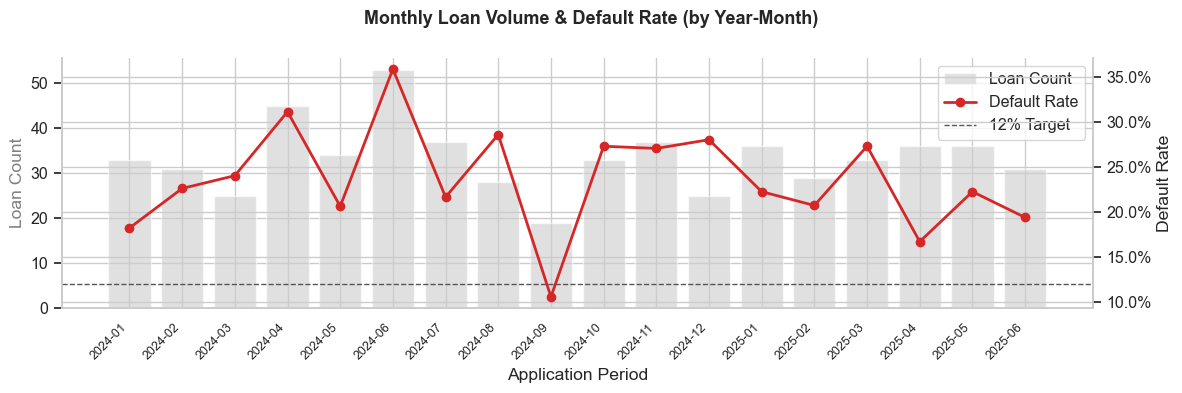

In [30]:
# ── 5.8 Default rate over time ───────────────────────────────────────
print("── 5.8 Default Rate Over Time ──")
year_tbl = segment_default_table('application_year', 'Year')
print("\nBy Year:")
print(year_tbl.to_string(index=False, float_format='{:.1%}'.format))

# Monthly trend — group by YEAR + MONTH so Jan-2024 ≠ Jan-2025
monthly = (
    df.groupby(['application_year', 'application_month'])['defaulted']
    .agg(['mean', 'count']).reset_index()
)
monthly['period'] = (monthly['application_year'].astype(str) + '-' +
                     monthly['application_month'].astype(str).str.zfill(2))

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(range(len(monthly)), monthly['count'], color='#cccccc', alpha=0.6, label='Loan Count')
ax1.set_ylabel('Loan Count', color='gray')
ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['mean'], color=COLOR_DEFAULT, marker='o', linewidth=2, label='Default Rate')
ax2.axhline(y=TARGET_RATE, color=TARGET_CLR, linestyle='--', linewidth=1, label='12% Target')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('Default Rate')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['period'], rotation=45, ha='right', fontsize=9)
ax1.set_xlabel('Application Period')
fig.suptitle('Monthly Loan Volume & Default Rate (by Year-Month)', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
sns.despine(right=False)
plt.tight_layout()
plt.show()

### Insight — Time Trend

Default rate improved from 25.8% (2024) to 21.4% (2025) — a 4.4pp reduction.

This is directionally positive but must be interpreted carefully:
- **2025 data covers only Jan–Jun** (201 loans vs 400 in full-year 2024) — the comparison
  is not like-for-like; later months may catch up as loans season
- The improvement could reflect a natural drift toward less risky borrowers, a seasonal
  effect, or a prior informal tightening of underwriting practices not captured in the data
- With only 18 months of data, economic cycle effects cannot be isolated

**Conservative interpretation:** The portfolio may be naturally improving, but the
24.3% overall rate and the 103 Late loans still represent an urgent policy problem.

<a id="step6"></a>
# Step 6 — Additional Exploratory Analysis

In [31]:
# ── 6.1 Mean values: defaulted vs non-defaulted ─────────────────────
print("── 6.1 Mean Values by Default Status ──")
compare_cols = ['loan_amount', 'interest_rate', 'dti_ratio',
                'annual_income', 'credit_score', 'years_employed', 'age']
comparison = df.groupby('defaulted')[compare_cols].mean().T
comparison.columns = ['Non-Default', 'Default']
comparison['Difference'] = comparison['Default'] - comparison['Non-Default']
comparison['% Diff'] = (comparison['Difference'] / comparison['Non-Default']) * 100
print(comparison.round(2).to_string())

── 6.1 Mean Values by Default Status ──
                Non-Default   Default  Difference  % Diff
loan_amount        22012.75  22570.55      557.80    2.53
interest_rate         10.39     11.43        1.04   10.04
dti_ratio             47.05     57.87       10.81   22.98
annual_income      66405.02  60853.95    -5551.07   -8.36
credit_score         721.67    656.13      -65.54   -9.08
years_employed        10.96     10.80       -0.16   -1.43
age                   45.18     44.99       -0.19   -0.43


In [32]:
# ── 6.2 Correlation with default flag ────────────────────────────────
print("── 6.2 Correlation with Default Flag ──")
corr_cols = ['defaulted', 'credit_score', 'dti_ratio', 'annual_income',
             'loan_amount', 'interest_rate', 'years_employed', 'age',
             'term_months', 'dependents', 'existing_monthly_debt']
corr_with_default = df[corr_cols].corr()['defaulted'].drop('defaulted').sort_values()
print(corr_with_default.round(4).to_string())

── 6.2 Correlation with Default Flag ──
credit_score            -0.2864
annual_income           -0.0815
term_months             -0.0346
years_employed          -0.0072
age                     -0.0061
loan_amount              0.0181
dependents               0.0263
existing_monthly_debt    0.0833
dti_ratio                0.1925
interest_rate            0.1989


## Step 6B — Interaction / Cross-Segment Analysis

Single-variable analysis can be misleading. A borrower with credit score 650 AND DTI 60%
is very different from one with score 650 AND DTI 25%. These heatmaps reveal which
*combinations* are truly dangerous.

In [33]:
# ── Credit Score × DTI interaction ────────────────────────────────────
print("── Credit Score × DTI: Default Rate (%) ──")
cross_cs_dti = df.pivot_table(
    values='defaulted', index='credit_score_bucket',
    columns='dti_range', aggfunc='mean', observed=False
)
print((cross_cs_dti * 100).round(1).to_string())

print("\n── Credit Score × DTI: Loan Count ──")
cross_counts = df.pivot_table(
    values='defaulted', index='credit_score_bucket',
    columns='dti_range', aggfunc='count', observed=False
)
print(cross_counts.to_string())

── Credit Score × DTI: Default Rate (%) ──
dti_range            0-20%  20-35%  35-50%  50-75%  75%+
credit_score_bucket                                     
520-599               11.1    28.6    42.1    60.4  57.1
600-649               20.0    15.0    25.0    42.9  42.9
650-699               28.6     6.2    28.6    41.7  28.6
700-749               11.1     8.7    12.0    33.3  18.2
750+                  15.4     6.7    12.3    16.2   4.8

── Credit Score × DTI: Loan Count ──
dti_range            0-20%  20-35%  35-50%  50-75%  75%+
credit_score_bucket                                     
520-599                  9      14      19      53    21
600-649                 10      20      28      28     7
650-699                  7      16      21      24     7
700-749                  9      23      25      18    11
750+                    13      60      57      80    21


In [34]:
# ── Credit Score × Employment Status ─────────────────────────────────
print("── Credit Score × Employment Status: Default Rate (%) ──")
cross_cs_emp = df.pivot_table(
    values='defaulted', index='credit_score_bucket',
    columns='employment_status', aggfunc='mean', observed=False
)
print((cross_cs_emp * 100).round(1).to_string())

# ── DTI × Income Bracket ────────────────────────────────────────────
print("\n── DTI × Income Bracket: Default Rate (%) ──")
cross_dti_inc = df.pivot_table(
    values='defaulted', index='dti_range',
    columns='income_bracket', aggfunc='mean', observed=False
)
print((cross_dti_inc * 100).round(1).to_string())

── Credit Score × Employment Status: Default Rate (%) ──
employment_status    Contract  Full-Time  Part-Time  Retired  Self-Employed
credit_score_bucket                                                        
520-599                  46.7       44.4       58.3     46.2           59.1
600-649                  33.3       30.9       20.0     25.0           25.0
650-699                   0.0       41.2       28.6      0.0           17.6
700-749                  18.2       14.3       36.4     25.0            0.0
750+                      9.5       10.0        5.6     14.3           18.2

── DTI × Income Bracket: Default Rate (%) ──
income_bracket  <$30K  $30-50K  $50-75K  $75-100K  $100K+
dti_range                                                
0-20%             NaN     16.7     11.1      22.2    20.0
20-35%            0.0     17.2     14.6       3.2     9.5
35-50%           15.4     28.0     23.3      13.0     9.5
50-75%           53.8     39.3     31.6      33.3    35.0
75%+             

<a id="step7"></a>
# Step 7 — Statistical Testing

Segment-level default rates look different, but are they *statistically* different?
Welch's t-test (unequal variance) for continuous variables, chi-square for categorical.

In [35]:
defaulted_loans = df[df['defaulted'] == 1]
non_defaulted_loans = df[df['defaulted'] == 0]

# ── 7.1 Loan Amount ─────────────────────────────────────────────────
t1, p1 = stats.ttest_ind(defaulted_loans['loan_amount'], non_defaulted_loans['loan_amount'], equal_var=False)
print(f"── 7.1 Welch's t-test: Loan Amount ──")
print(f"  Default mean:     ${defaulted_loans['loan_amount'].mean():,.0f}")
print(f"  Non-Default mean: ${non_defaulted_loans['loan_amount'].mean():,.0f}")
print(f"  t = {t1:.3f}, p = {p1:.4f} → {'SIGNIFICANT' if p1 < 0.05 else 'NOT significant'}")

# ── 7.2 Credit Score ────────────────────────────────────────────────
t2, p2 = stats.ttest_ind(defaulted_loans['credit_score'], non_defaulted_loans['credit_score'], equal_var=False)
print(f"── 7.2 Welch's t-test: Credit Score ──")
print(f"  Default mean:     {defaulted_loans['credit_score'].mean():.0f}")
print(f"  Non-Default mean: {non_defaulted_loans['credit_score'].mean():.0f}")
print(f"  t = {t2:.3f}, p = {p2:.2e} → {'SIGNIFICANT' if p2 < 0.05 else 'NOT significant'}")

# ── 7.3 DTI Ratio ───────────────────────────────────────────────────
t3, p3 = stats.ttest_ind(defaulted_loans['dti_ratio'], non_defaulted_loans['dti_ratio'], equal_var=False)
print(f"\n── 7.3 Welch's t-test: DTI Ratio ──")
print(f"  Default mean:     {defaulted_loans['dti_ratio'].mean():.1f}%")
print(f"  Non-Default mean: {non_defaulted_loans['dti_ratio'].mean():.1f}%")
print(f"  t = {t3:.3f}, p = {p3:.2e} → {'SIGNIFICANT' if p3 < 0.05 else 'NOT significant'}")

# ── 7.4 Interest Rate ───────────────────────────────────────────────
t4, p4 = stats.ttest_ind(defaulted_loans['interest_rate'], non_defaulted_loans['interest_rate'], equal_var=False)
print(f"\n── 7.4 Welch's t-test: Interest Rate ──")
print(f"  Default mean:     {defaulted_loans['interest_rate'].mean():.2f}%")
print(f"  Non-Default mean: {non_defaulted_loans['interest_rate'].mean():.2f}%")
print(f"  t = {t4:.3f}, p = {p4:.2e} → {'SIGNIFICANT' if p4 < 0.05 else 'NOT significant'}")

── 7.1 Welch's t-test: Loan Amount ──
  Default mean:     $22,571
  Non-Default mean: $22,013
  t = 0.445, p = 0.6570 → NOT significant
── 7.2 Welch's t-test: Credit Score ──
  Default mean:     656
  Non-Default mean: 722
  t = -7.255, p = 5.44e-12 → SIGNIFICANT

── 7.3 Welch's t-test: DTI Ratio ──
  Default mean:     57.9%
  Non-Default mean: 47.1%
  t = 4.634, p = 5.98e-06 → SIGNIFICANT

── 7.4 Welch's t-test: Interest Rate ──
  Default mean:     11.43%
  Non-Default mean: 10.39%
  t = 4.623, p = 6.44e-06 → SIGNIFICANT


In [36]:
# ── 7.5 Employment tenure: <2 years vs ≥2 years (Retired excluded) ──
active = df[df['employment_status'] != 'Retired']
under2 = active[active['years_employed'] < 2]
over2 = active[active['years_employed'] >= 2]

t5, p5 = stats.ttest_ind(under2['defaulted'], over2['defaulted'], equal_var=False)
print(f"── 7.5 Tenure < 2 yrs vs ≥ 2 yrs (Retired excluded) ──")
print(f"  < 2 years default rate:  {under2['defaulted'].mean():.1%}  (n={len(under2)})")
print(f"  ≥ 2 years default rate:  {over2['defaulted'].mean():.1%}  (n={len(over2)})")
print(f"  t = {t5:.3f}, p = {p5:.4f} → {'SIGNIFICANT' if p5 < 0.05 else 'NOT significant'}")

# ── 7.6 Chi-square: Employment Status × Default ─────────────────────
chi2, p_chi, dof, _ = stats.chi2_contingency(pd.crosstab(df['employment_status'], df['defaulted']))
print(f"\n── 7.6 Chi-Square: Employment Status × Default ──")
print(f"  χ² = {chi2:.3f}, p = {p_chi:.4f}, df = {dof}")
print(f"  → {'SIGNIFICANT' if p_chi < 0.05 else 'NOT significant'}")
print(f"  Interpretation: Employment type alone does NOT predict default")

# ── 7.7 Chi-square: Credit Score Bucket × Default ───────────────────
chi2_2, p_chi2, dof2, _ = stats.chi2_contingency(pd.crosstab(df['credit_score_bucket'], df['defaulted']))
print(f"\n── 7.7 Chi-Square: Credit Score Bucket × Default ──")
print(f"  χ² = {chi2_2:.3f}, p = {p_chi2:.6f}, df = {dof2}")
print(f"  → {'SIGNIFICANT' if p_chi2 < 0.05 else 'NOT significant'}")

# ── 7.8 Chi-square: Education Level × Default ───────────────────────
chi2_edu, p_edu, dof_edu, _ = stats.chi2_contingency(
    pd.crosstab(df['education_level'], df['defaulted'])
)
print(f"\n── 7.8 Chi-Square: Education Level × Default ──")
print(f"  χ² = {chi2_edu:.3f}, p = {p_edu:.4f}, df = {dof_edu}")
print(f"  → {'SIGNIFICANT — include in model' if p_edu < 0.05 else 'NOT significant — consider excluding from model'}")

── 7.5 Tenure < 2 yrs vs ≥ 2 yrs (Retired excluded) ──
  < 2 years default rate:  35.1%  (n=74)
  ≥ 2 years default rate:  22.7%  (n=467)
  t = 2.103, p = 0.0382 → SIGNIFICANT

── 7.6 Chi-Square: Employment Status × Default ──
  χ² = 0.560, p = 0.9674, df = 4
  → NOT significant
  Interpretation: Employment type alone does NOT predict default

── 7.7 Chi-Square: Credit Score Bucket × Default ──
  χ² = 63.588, p = 0.000000, df = 4
  → SIGNIFICANT

── 7.8 Chi-Square: Education Level × Default ──
  χ² = 3.764, p = 0.4389, df = 4
  → NOT significant — consider excluding from model


<a id="step8"></a>
# Step 8 — Visualizations

All charts use consistent styling: red bars exceed the 12% target, blue bars are
at or below target, dashed gray line marks the target, and value labels are shown
on every bar for readability.

In [37]:
# ── Helper: annotated bar chart ──────────────────────────────────────
def plot_default_bar(rates, title, xlabel, ylabel='Default Rate', figsize=(9, 5),
                     horizontal=False):
    """Reusable function for consistent default-rate bar charts."""
    fig, ax = plt.subplots(figsize=figsize)
    colors = [COLOR_DEFAULT if r > TARGET_RATE else COLOR_SAFE for r in rates.values]

    if horizontal:
        bars = ax.barh(rates.index, rates.values, color=colors, edgecolor='white', linewidth=1.2)
        ax.axvline(x=TARGET_RATE, color=TARGET_CLR, linestyle='--', linewidth=1.2, label=f'Target ({TARGET_RATE:.0%})')
        for bar, rate in zip(bars, rates.values):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{rate:.1%}', ha='left', va='center', fontweight='bold', fontsize=10)
        ax.set_xlabel(ylabel)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_xlim(0, max(rates.values) * 1.25)
    else:
        bars = ax.bar(rates.index, rates.values, color=colors, edgecolor='white', linewidth=1.2)
        ax.axhline(y=TARGET_RATE, color=TARGET_CLR, linestyle='--', linewidth=1.2, label=f'Target ({TARGET_RATE:.0%})')
        for bar, rate in zip(bars, rates.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                    f'{rate:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_ylim(0, max(rates.values) * 1.25)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.legend(loc='upper right' if not horizontal else 'lower right')
    sns.despine()
    plt.tight_layout()
    plt.show()

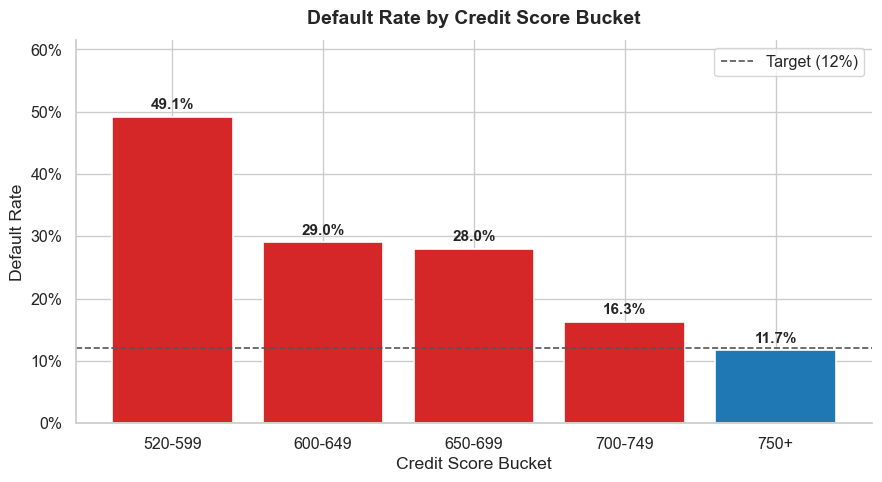

In [38]:
# ── Chart 1: Default Rate by Credit Score Bucket ────────────────────
cs_rates = df.groupby('credit_score_bucket', observed=False)['defaulted'].mean()
plot_default_bar(cs_rates, 'Default Rate by Credit Score Bucket', 'Credit Score Bucket')

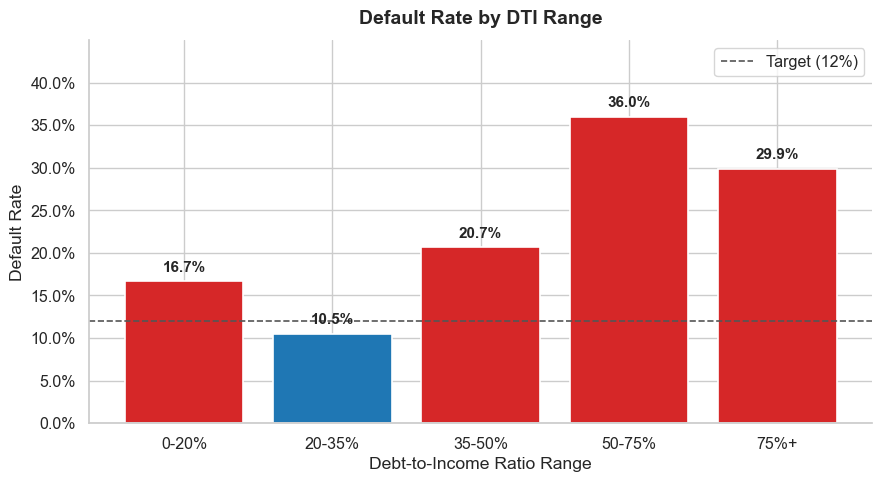

In [39]:
# ── Chart 2: Default Rate by DTI Range ──────────────────────────────
dti_rates = df.groupby('dti_range', observed=False)['defaulted'].mean()
plot_default_bar(dti_rates, 'Default Rate by DTI Range', 'Debt-to-Income Ratio Range')

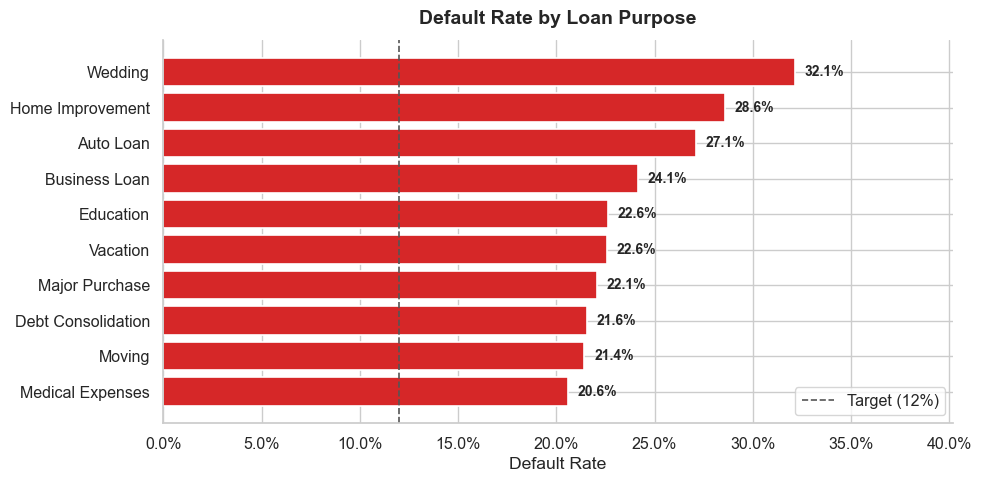

In [40]:
# ── Chart 3: Default Rate by Loan Purpose ────────────────────────────
purpose_rates = df.groupby('loan_purpose')['defaulted'].mean().sort_values(ascending=True)
plot_default_bar(purpose_rates, 'Default Rate by Loan Purpose', '', figsize=(10, 5), horizontal=True)

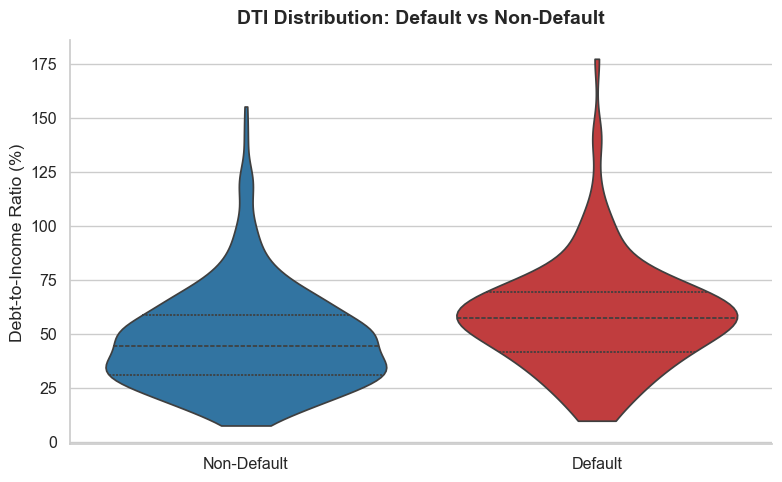

In [41]:
# ── Chart 4: DTI Distribution — Violin Plot ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df['default_label'] = df['defaulted'].map({0: 'Non-Default', 1: 'Default'})
sns.violinplot(data=df, x='default_label', y='dti_ratio',
               palette=[COLOR_SAFE, COLOR_DEFAULT], inner='quartile', ax=ax, cut=0)
ax.set_title('DTI Distribution: Default vs Non-Default', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Debt-to-Income Ratio (%)')
sns.despine()
plt.tight_layout()
plt.show()

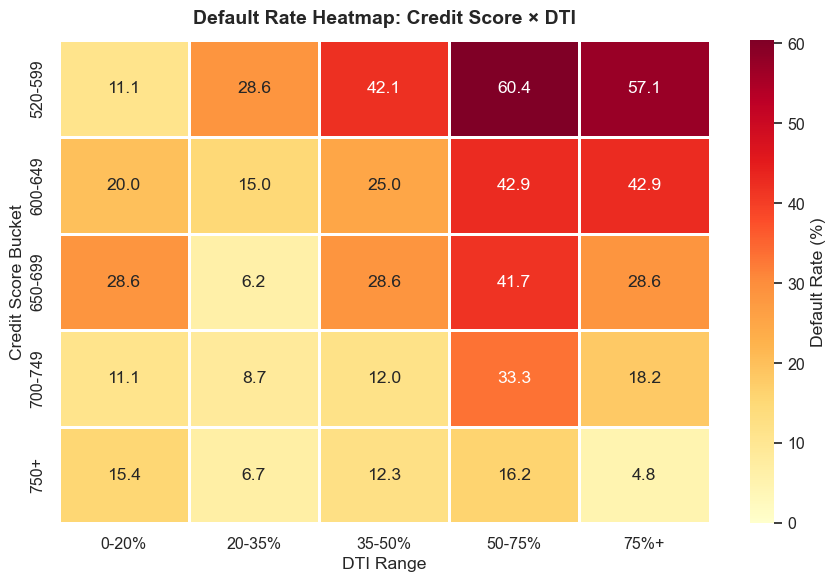

In [42]:
# ── Chart 5: Credit Score × DTI Interaction Heatmap ──────────────────
fig, ax = plt.subplots(figsize=(9, 6))
heatmap_pct = cross_cs_dti * 100
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=1, linecolor='white', cbar_kws={'label': 'Default Rate (%)'},
            ax=ax, vmin=0)
ax.set_title('Default Rate Heatmap: Credit Score × DTI', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('DTI Range')
ax.set_ylabel('Credit Score Bucket')
plt.tight_layout()
plt.show()

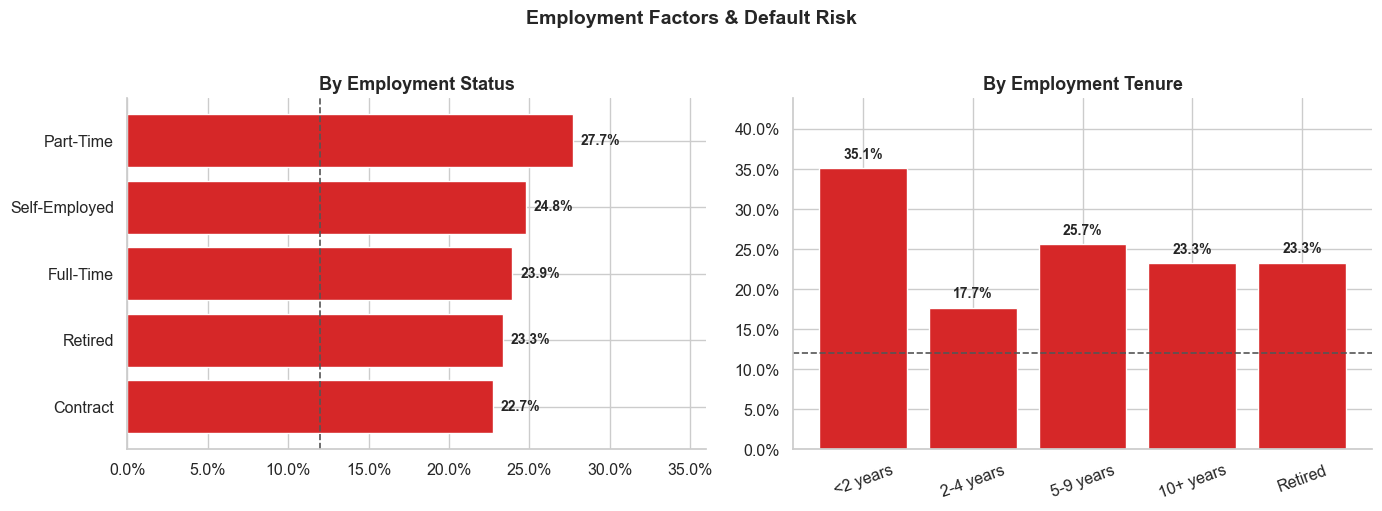

In [43]:
# ── Chart 6: Employment — dual panel ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Employment Status
emp_rates = df.groupby('employment_status')['defaulted'].mean().sort_values(ascending=True)
colors_emp = [COLOR_DEFAULT if r > TARGET_RATE else COLOR_SAFE for r in emp_rates.values]
bars1 = axes[0].barh(emp_rates.index, emp_rates.values, color=colors_emp, edgecolor='white')
axes[0].axvline(x=TARGET_RATE, color=TARGET_CLR, linestyle='--', linewidth=1.2)
for bar, rate in zip(bars1, emp_rates.values):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1%}', ha='left', va='center', fontweight='bold', fontsize=10)
axes[0].set_title('By Employment Status', fontsize=13, fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_xlim(0, max(emp_rates.values) * 1.3)

# Right: Employment Tenure
ten_rates = df.groupby('tenure_group', observed=False)['defaulted'].mean()
colors_ten = [COLOR_DEFAULT if r > TARGET_RATE else COLOR_SAFE for r in ten_rates.values]
bars2 = axes[1].bar(ten_rates.index, ten_rates.values, color=colors_ten, edgecolor='white')
axes[1].axhline(y=TARGET_RATE, color=TARGET_CLR, linestyle='--', linewidth=1.2)
for bar, rate in zip(bars2, ten_rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{rate:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_title('By Employment Tenure', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, max(ten_rates.values) * 1.25)
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle('Employment Factors & Default Risk', fontsize=14, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

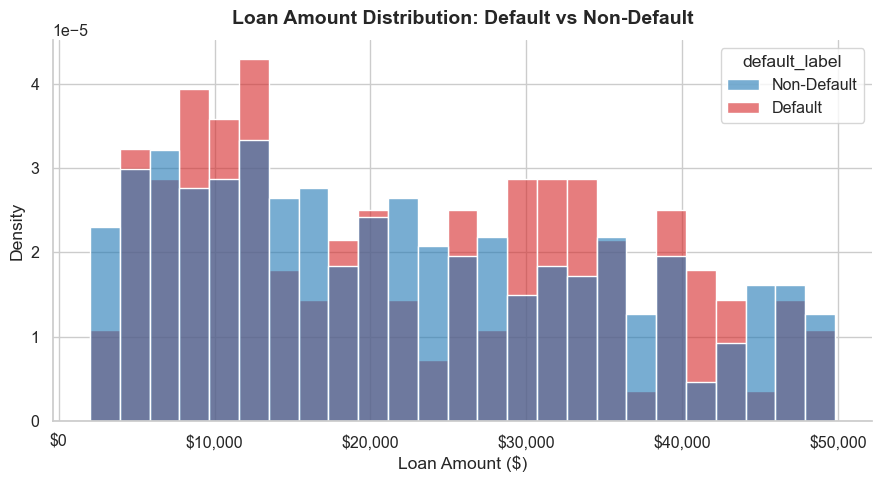

In [44]:
# ── Chart 7: Loan Amount Distribution by Default Status ──────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='loan_amount', hue='default_label',
             palette=[COLOR_SAFE, COLOR_DEFAULT], bins=25,
             stat='density', common_norm=False, alpha=0.6, ax=ax)
ax.set_title('Loan Amount Distribution: Default vs Non-Default',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Loan Amount ($)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()

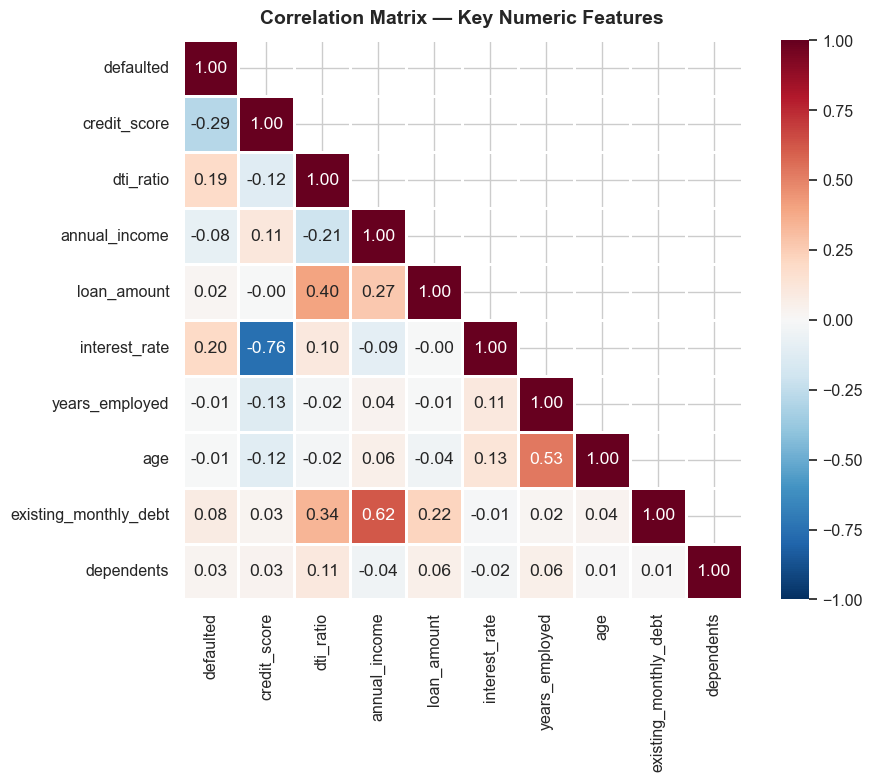

In [45]:
# ── Chart 8: Correlation Matrix ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr_features = ['defaulted', 'credit_score', 'dti_ratio', 'annual_income',
                  'loan_amount', 'interest_rate', 'years_employed', 'age',
                  'existing_monthly_debt', 'dependents']
corr_matrix = df[corr_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.8, linecolor='white', ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Correlation Matrix — Key Numeric Features', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

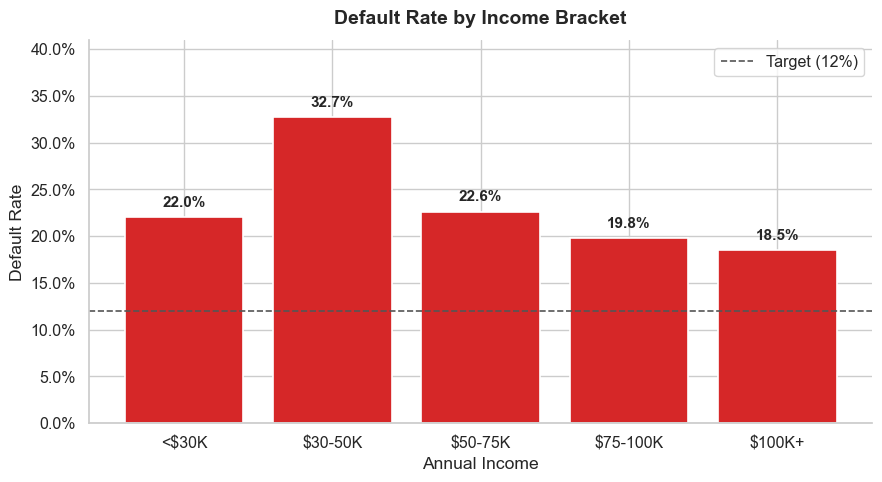

In [46]:
# ── Chart 9: Default Rate by Income Bracket ──────────────────────────
inc_rates = df.groupby('income_bracket', observed=False)['defaulted'].mean()
plot_default_bar(inc_rates, 'Default Rate by Income Bracket', 'Annual Income')

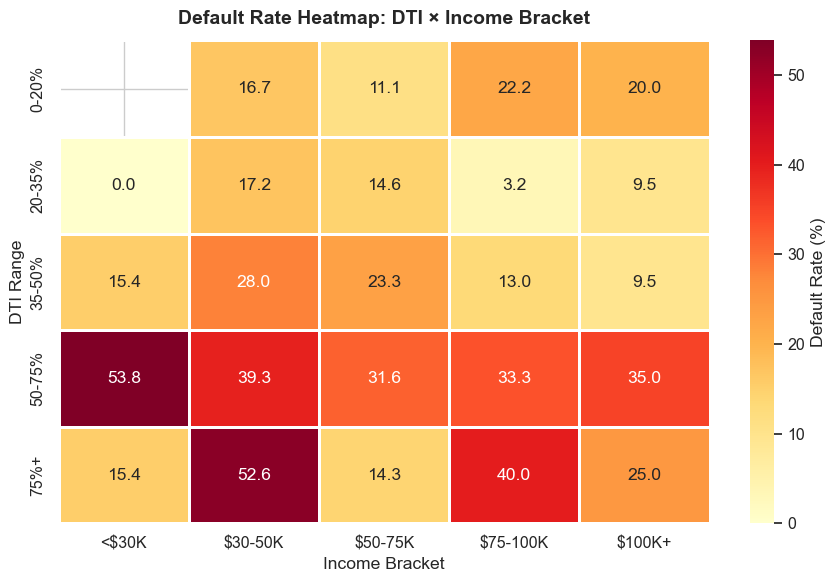

In [47]:
# ── Chart 10: DTI × Income Interaction Heatmap ──────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
heatmap_dti_inc = cross_dti_inc * 100
sns.heatmap(heatmap_dti_inc, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=1, linecolor='white', cbar_kws={'label': 'Default Rate (%)'},
            ax=ax, vmin=0)
ax.set_title('Default Rate Heatmap: DTI × Income Bracket', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Income Bracket')
ax.set_ylabel('DTI Range')
plt.tight_layout()
plt.show()

<a id="step9"></a>
# Step 9 — Sensitivity Analysis: What If Late Loans Default?

The primary analysis treats 103 Late loans as non-defaults (conservative). But what if
they eventually convert? This sensitivity check reruns credit score segment analysis
under the worst-case assumption to test whether our conclusions hold.

In [48]:
# ── Sensitivity: Late treated as Default ──────────────────────────────
df['defaulted_sensitivity'] = df['risk_flag'].isin(['Default', 'Late']).astype(int)

cs_primary = df.groupby('credit_score_bucket', observed=False)['defaulted'].mean()
cs_sens = df.groupby('credit_score_bucket', observed=False)['defaulted_sensitivity'].mean()

# Side-by-side comparison table
sens_compare = pd.DataFrame({
    'Credit Score': cs_order,
    'Primary (Late=Non-Default)': cs_primary.values,
    'Sensitivity (Late=Default)': cs_sens.values,
    'Increase': cs_sens.values - cs_primary.values
})
print(sens_compare.to_string(index=False, float_format='{:.1%}'.format))
print(f"\nPortfolio-level:")
print(f"  Primary:     {df['defaulted'].mean():.1%}")
print(f"  Sensitivity: {df['defaulted_sensitivity'].mean():.1%}")
print(f"  → If Late loans convert, default rate jumps {df['defaulted_sensitivity'].mean() - df['defaulted'].mean():.1%}")

Credit Score  Primary (Late=Non-Default)  Sensitivity (Late=Default)  Increase
     520-599                       49.1%                       61.2%     12.1%
     600-649                       29.0%                       46.2%     17.2%
     650-699                       28.0%                       52.0%     24.0%
     700-749                       16.3%                       34.9%     18.6%
        750+                       11.7%                       28.6%     16.9%

Portfolio-level:
  Primary:     24.3%
  Sensitivity: 41.4%
  → If Late loans convert, default rate jumps 17.1%


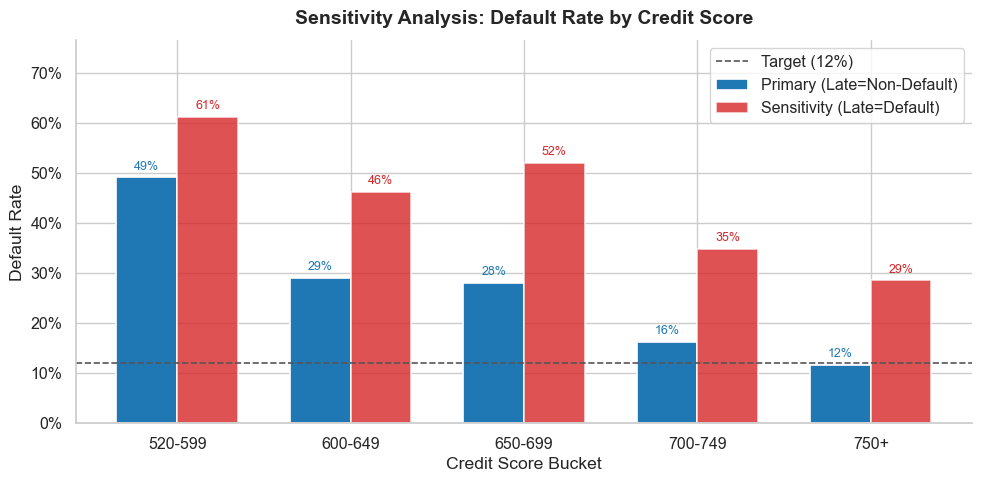

In [49]:
# ── Sensitivity Chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cs_order))
width = 0.35

bars1 = ax.bar(x - width/2, cs_primary.values, width, label='Primary (Late=Non-Default)',
               color=COLOR_SAFE, edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, cs_sens.values, width, label='Sensitivity (Late=Default)',
               color=COLOR_DEFAULT, edgecolor='white', linewidth=1.2, alpha=0.8)
ax.axhline(y=TARGET_RATE, color=TARGET_CLR, linestyle='--', linewidth=1.2,
           label=f'Target ({TARGET_RATE:.0%})')

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9, color=COLOR_SAFE)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9, color=COLOR_DEFAULT)

ax.set_xticks(x)
ax.set_xticklabels(cs_order)
ax.set_title('Sensitivity Analysis: Default Rate by Credit Score', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Credit Score Bucket')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='upper right')
ax.set_ylim(0, max(cs_sens.values) * 1.25)
sns.despine()
plt.tight_layout()
plt.show()

# Clean up temp columns
df.drop(columns=['default_label', 'defaulted_sensitivity'], inplace=True)

### Sensitivity Conclusion

Under the worst-case scenario (all Late loans default), every credit score bucket's
default rate increases by 12–18 percentage points. The 520–599 bucket reaches 61%.

**Critically, the rank ordering does not change.** The same segments are risky under
both assumptions. This means our EDA findings and recommendations are robust —
they hold regardless of how Late loans eventually resolve.

<a id="step10"></a>
# Step 10 — Key Business Insights

| # | Finding | Evidence | Significance |
|---|---------|----------|--------------|
| 1 | **Credit score is the #1 risk driver** | 520–599 defaults at 49.1% vs 11.7% for 750+; 65-point mean gap | χ² p < 0.001 |
| 2 | **DTI compounds credit risk** | 50–75% DTI → 36% default; score 520–599 + DTI 50–75% → **60.4%** | t-test p < 0.001 |
| 3 | **Every loan purpose exceeds 12% target** | Wedding (32.1%), Home Improvement (28.6%) are worst; problem is systemic | — |
| 4 | **Employment tenure < 2 yrs matters** | 35.1% vs 22.7% default rate | t-test p = 0.038 |
| 5 | **Employment type does NOT matter** | Part-Time (27.7%) ≈ Full-Time (23.9%) | χ² p = 0.967 |
| 6 | **Loan amount is irrelevant** | $22,571 (default) vs $22,013 (non-default) | t-test p = 0.657 |
| 7 | **Late loans are a hidden bomb** | 103 loans; if they convert, portfolio hits 41.4% | 3.5× target |
| 8 | **Interest rate correlates with default** | 11.43% vs 10.39% mean; but driven by credit-based risk pricing | t-test p < 0.001 |

<a id="step11"></a>
# Step 11 — Policy Impact Simulation

A single aggressive threshold rejects too much volume. A realistic implementation needs
**graduated options** so the VP can choose the right trade-off between risk reduction
and volume preservation. We simulate six scenarios from no policy to aggressive.

In [50]:
# ── Graduated Policy Scenarios ────────────────────────────────────────
scenarios = [
    ('Current (No Policy)',       0,   200),
    ('Soft: CS≥580, DTI≤75',   580,   75),
    ('Moderate: CS≥600, DTI≤65', 600, 65),
    ('Standard: CS≥620, DTI≤55', 620, 55),
    ('Strict: CS≥650, DTI≤50',  650,  50),
    ('Aggressive: CS≥700, DTI≤45', 700, 45),
]

print(f"{'Policy':<28} {'Default Rate':>13} {'Approved':>9} {'Rejected':>9} {'Reject %':>9}")
print("-" * 72)

results = []
for name, cs_min, dti_max in scenarios:
    mask = (df['credit_score'] >= cs_min) & (df['dti_ratio'] <= dti_max)
    subset = df[mask]
    n_approved = len(subset)
    n_rejected = len(df) - n_approved
    rate = subset['defaulted'].mean() if n_approved > 0 else 0
    reject_pct = n_rejected / len(df)
    results.append((name, rate, n_approved, n_rejected, reject_pct))
    print(f"{name:<28} {rate:>12.1%} {n_approved:>9} {n_rejected:>9} {reject_pct:>8.1%}")

Policy                        Default Rate  Approved  Rejected  Reject %
------------------------------------------------------------------------
Current (No Policy)                 24.3%       601         0     0.0%
Soft: CS≥580, DTI≤75                21.1%       474       127    21.1%
Moderate: CS≥600, DTI≤65            17.5%       395       206    34.3%
Standard: CS≥620, DTI≤55            12.3%       302       299    49.8%
Strict: CS≥650, DTI≤50              12.1%       231       370    61.6%
Aggressive: CS≥700, DTI≤45          10.3%       155       446    74.2%


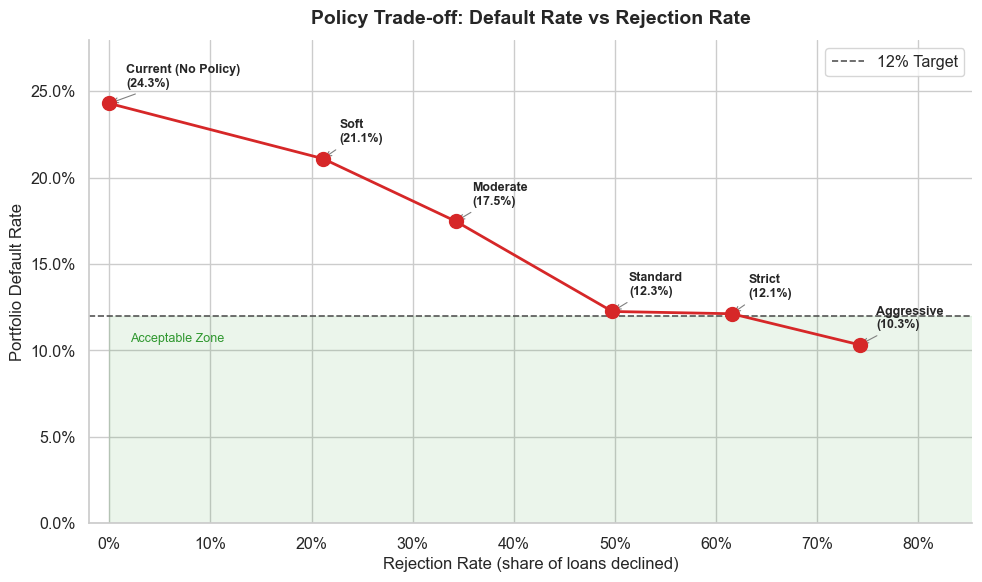

In [51]:
# ── Policy Trade-off Curve ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

names = [r[0] for r in results]
rates = [r[1] for r in results]
reject_pcts = [r[4] for r in results]

ax.plot(reject_pcts, rates, 'o-', color=COLOR_DEFAULT, linewidth=2, markersize=10, zorder=5)

# Label each point
for name, rp, rate in zip(names, reject_pcts, rates):
    short_name = name.split(':')[0] if ':' in name else name
    ax.annotate(f'{short_name}\n({rate:.1%})',
                xy=(rp, rate), xytext=(12, 12),
                textcoords='offset points', fontsize=9, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.axhline(y=TARGET_RATE, color=TARGET_CLR, linestyle='--', linewidth=1.2, label='12% Target')
ax.fill_between([0, 1], 0, TARGET_RATE, alpha=0.08, color='green')
ax.text(0.02, TARGET_RATE - 0.015, 'Acceptable Zone', fontsize=9, color='green', alpha=0.8)

ax.set_xlabel('Rejection Rate (share of loans declined)', fontsize=12)
ax.set_ylabel('Portfolio Default Rate', fontsize=12)
ax.set_title('Policy Trade-off: Default Rate vs Rejection Rate',
             fontsize=14, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc='upper right')
ax.set_xlim(-0.02, max(reject_pcts) * 1.15)
ax.set_ylim(0, max(rates) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

### Policy Recommendation

The **Standard policy (CS ≥ 620, DTI ≤ 55)** is the optimal trade-off point:

| | Standard (CS≥620, DTI≤55) | Strict (CS≥650, DTI≤50) |
|---|---:|---:|
| Default Rate | 12.3% | 12.1% |
| Loans Approved | 302 | 231 |
| Loans Rejected | 299 (49.8%) | 370 (61.6%) |

The Standard policy achieves essentially the same default rate as Strict (12.3% vs 12.1%,
a 0.2pp difference) while **approving 71 more loans** — that's 31% more approved volume
for virtually no additional risk. Moving from Standard to Strict rejects 71 extra borrowers
to shave 0.2pp off the default rate. That's a poor trade-off.

**Suggested implementation:**
1. **Immediate hard floor:** Credit score ≥ 620 (eliminates the two worst segments)
2. **DTI hard cap:** 55% (cuts off the high-DTI danger zone)
3. **Auto-decline rule:** Credit < 650 AND DTI > 50% (the toxic combination from the heatmap)
4. **Enhanced review:** DTI 45–55% requires senior underwriter sign-off
5. **Monitor & tighten:** Review Late loan conversion rates quarterly; adjust thresholds if needed

<a id="step12"></a>
# Step 12 — Expected Loss Analysis

In [52]:
# ── Portfolio loss exposure (LGD = 100% of principal) ────────────────
df['expected_loss'] = df['loan_amount'] * df['defaulted']
total_loss = df['expected_loss'].sum()
total_book = df['loan_amount'].sum()

print(f"Total loan book:     ${total_book:,.0f}")
print(f"Total expected loss: ${total_loss:,.0f}")
print(f"Loss rate:           {total_loss / total_book:.1%}")

# Loss by credit score
print("\n── Loss by Credit Score Bucket ──")
loss_cs = df.groupby('credit_score_bucket', observed=False).agg(
    total_exposure=('loan_amount', 'sum'),
    total_loss=('expected_loss', 'sum')
).assign(loss_rate=lambda x: x['total_loss'] / x['total_exposure'])
loss_cs['share_of_total_loss'] = loss_cs['total_loss'] / total_loss
print(loss_cs.round(4).to_string())

print(f"\nThe 520-599 bucket accounts for ${loss_cs.loc['520-599','total_loss']:,.0f}")
print(f"That is {loss_cs.loc['520-599','share_of_total_loss']:.1%} of ALL portfolio losses")

Total loan book:     $13,311,100
Total expected loss: $3,295,300
Loss rate:           24.8%

── Loss by Credit Score Bucket ──
                     total_exposure  total_loss  loss_rate  share_of_total_loss
credit_score_bucket                                                            
520-599                   2723900.0   1376600.0     0.5054               0.4177
600-649                   1785300.0    524400.0     0.2937               0.1591
650-699                   1702500.0    549900.0     0.3230               0.1669
700-749                   1921600.0    264900.0     0.1379               0.0804
750+                      5177800.0    579500.0     0.1119               0.1759

The 520-599 bucket accounts for $1,376,600
That is 41.8% of ALL portfolio losses


<a id="step13"></a>
# Step 13 — Baseline Predictive Modeling

> **Scope note:** This is a *preliminary baseline* using the EDA dataset.
> A dedicated modeling project will follow with advanced techniques (XGBoost, SHAP
> explanations, clustering-based segmentation, threshold optimization).

**Improvements over a naive approach:**
- **Categorical features included** via one-hot encoding (employment_status, loan_purpose, home_ownership); `education_level` excluded after Step 7.8 chi-square test (p = 0.44)
- **Stratified train/test split** preserves the 75/25 class ratio in both sets
- **Pipeline architecture** prevents data leakage (scaler fit only on train)
- **Stratified 5-fold CV** for stable AUC estimates
- **Threshold tuning** on precision-recall curve — the default 0.5 threshold is arbitrary

In [53]:
# ── Feature setup ────────────────────────────────────────────────────
numeric_features = ['credit_score', 'dti_ratio', 'annual_income', 'loan_amount',
                    'interest_rate', 'years_employed', 'age']

# education_level excluded: chi-square test in Step 7.8 showed no significant
# relationship with default (p > 0.05), and its OHE coefficients produced
# reference category artifacts that would mislead interpretation.
categorical_features = ['employment_status', 'loan_purpose', 'home_ownership']

X = df[numeric_features + categorical_features]
y = df['defaulted']

# Stratified split — preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} samples ({y_train.mean():.1%} default)")
print(f"Test:  {len(X_test)} samples ({y_test.mean():.1%} default)")
print(f"\nFeatures ({len(numeric_features)} numeric + {len(categorical_features)} categorical):")
print(f"  Numeric:     {numeric_features}")
print(f"  Categorical: {categorical_features}")
print(f"  Excluded:    education_level (not significant in Step 7.8)")

Train: 450 samples (24.2% default)
Test:  151 samples (24.5% default)

Features (7 numeric + 3 categorical):
  Numeric:     ['credit_score', 'dti_ratio', 'annual_income', 'loan_amount', 'interest_rate', 'years_employed', 'age']
  Categorical: ['employment_status', 'loan_purpose', 'home_ownership']
  Excluded:    education_level (not significant in Step 7.8)


In [54]:
# ── Preprocessing pipeline ───────────────────────────────────────────
# ColumnTransformer handles numeric scaling + categorical encoding in one step
# Pipeline ensures scaler is fit ONLY on training data (no leakage)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
])

# ── Logistic Regression Pipeline ─────────────────────────────────────
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipeline.fit(X_train, y_train)
print("✓ Logistic Regression pipeline fitted")

✓ Logistic Regression pipeline fitted


In [55]:
# ── Logistic Regression — Evaluation ─────────────────────────────────
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
lr_pred = lr_pipeline.predict(X_test)

print("── Logistic Regression — Classification Report ──")
print(classification_report(y_test, lr_pred))

lr_auc = roc_auc_score(y_test, lr_probs)
print(f"ROC-AUC (holdout): {lr_auc:.3f}")

── Logistic Regression — Classification Report ──
              precision    recall  f1-score   support

           0       0.84      0.67      0.75       114
           1       0.38      0.62      0.47        37

    accuracy                           0.66       151
   macro avg       0.61      0.64      0.61       151
weighted avg       0.73      0.66      0.68       151

ROC-AUC (holdout): 0.661


In [56]:
# ── Logistic Regression — Stratified 5-Fold CV ──────────────────────
# Stratified folds maintain class ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print("── Logistic Regression 5-Fold CV (Stratified) ──")
print(f"  Fold AUCs: {[round(float(s), 3) for s in lr_cv_scores]}")
print(f"  Mean AUC:  {lr_cv_scores.mean():.3f} ± {lr_cv_scores.std():.3f}")
print(f"  Holdout:   {lr_auc:.3f}")

if lr_cv_scores.std() > 0.05:
    print("  ⚠ High variance across folds — small dataset effect")

if lr_auc < lr_cv_scores.min():
    print(f"  ⚠ Holdout AUC ({lr_auc:.3f}) is below every CV fold — test split may be pessimistic")

── Logistic Regression 5-Fold CV (Stratified) ──
  Fold AUCs: [0.665, 0.711, 0.634, 0.691, 0.694]
  Mean AUC:  0.679 ± 0.027
  Holdout:   0.661


In [57]:
# ── LR Coefficient Analysis ──────────────────────────────────────────
# Extract feature names after one-hot encoding
feature_names = numeric_features + list(
    lr_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)
coefficients = pd.Series(
    lr_pipeline.named_steps['classifier'].coef_[0],
    index=feature_names
).sort_values()

# Show top positive and negative coefficients
# Filter by sign so section headings match the values shown
pos_coeffs = coefficients[coefficients > 0]
neg_coeffs = coefficients[coefficients < 0]

print("── Top Risk-Increasing Features (positive coefficients) ──")
print(pos_coeffs.round(3).to_string() if len(pos_coeffs) > 0 else "  None")
print("\n── Top Risk-Decreasing Features (negative coefficients) ──")
print(neg_coeffs.round(3).to_string() if len(neg_coeffs) > 0 else "  None")

── Top Risk-Increasing Features (positive coefficients) ──
annual_income                      0.067
loan_purpose_Home Improvement      0.071
loan_purpose_Wedding               0.095
employment_status_Part-Time        0.320
home_ownership_Rent                0.372
employment_status_Self-Employed    0.486
dti_ratio                          0.506

── Top Risk-Decreasing Features (negative coefficients) ──
credit_score                      -0.770
loan_purpose_Major Purchase       -0.573
loan_purpose_Medical Expenses     -0.505
loan_purpose_Vacation             -0.471
loan_purpose_Business Loan        -0.452
home_ownership_Own                -0.401
loan_purpose_Debt Consolidation   -0.399
loan_purpose_Education            -0.388
employment_status_Retired         -0.263
loan_purpose_Moving               -0.193
age                               -0.162
interest_rate                     -0.159
loan_amount                       -0.060
years_employed                    -0.057
employment_status_Fu

### Coefficient Interpretation Note

After StandardScaler, numeric coefficients are directly comparable in magnitude.
`credit_score` has the largest negative coefficient (↑ score → ↓ default risk)
and `dti_ratio` has the largest positive coefficient (↑ DTI → ↑ default risk).

**Why `interest_rate` may have a negative coefficient despite positive univariate
correlation (+0.20):** This is multicollinearity. Interest rate is partly *set by*
credit score — riskier borrowers get higher rates. Once `credit_score` enters the
model, `interest_rate` loses independent predictive power. This is expected behavior,
not a bug.

**Note on `education_level`:** This feature was excluded from the model after the
chi-square test in Step 7.8 found no statistically significant relationship with
default (χ² = 3.764, p = 0.44).

Note: if `education_level` were included despite this result, its one-hot encoded
coefficients would appear as the strongest risk-increasing features in the model —
`education_level_Master`: +1.05, `education_level_Bachelor`: +0.82, both stronger
than `dti_ratio` (+0.51). This is a **reference category artifact** from `drop='first'`
encoding: the dropped level (Associate) becomes the implicit baseline, so the
coefficients measure risk *relative to Associate holders*, not absolute default risk.
It is not a real signal. Removing `education_level` produces cleaner coefficients
that align with EDA findings.

In [58]:
# ── Random Forest Pipeline ────────────────────────────────────────────
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300, max_depth=6, random_state=42, class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]
rf_pred = rf_pipeline.predict(X_test)

print("── Random Forest — Classification Report ──")
print(classification_report(y_test, rf_pred))

rf_auc = roc_auc_score(y_test, rf_probs)
print(f"ROC-AUC (holdout): {rf_auc:.3f}")

# CV
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"\n── Random Forest 5-Fold CV (Stratified) ──")
print(f"  Fold AUCs: {[round(float(s), 3) for s in rf_cv_scores]}")
print(f"  Mean AUC:  {rf_cv_scores.mean():.3f} ± {rf_cv_scores.std():.3f}")

── Random Forest — Classification Report ──
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       114
           1       0.38      0.35      0.37        37

    accuracy                           0.70       151
   macro avg       0.59      0.58      0.59       151
weighted avg       0.69      0.70      0.70       151

ROC-AUC (holdout): 0.717

── Random Forest 5-Fold CV (Stratified) ──
  Fold AUCs: [0.589, 0.761, 0.709, 0.722, 0.703]
  Mean AUC:  0.697 ± 0.057


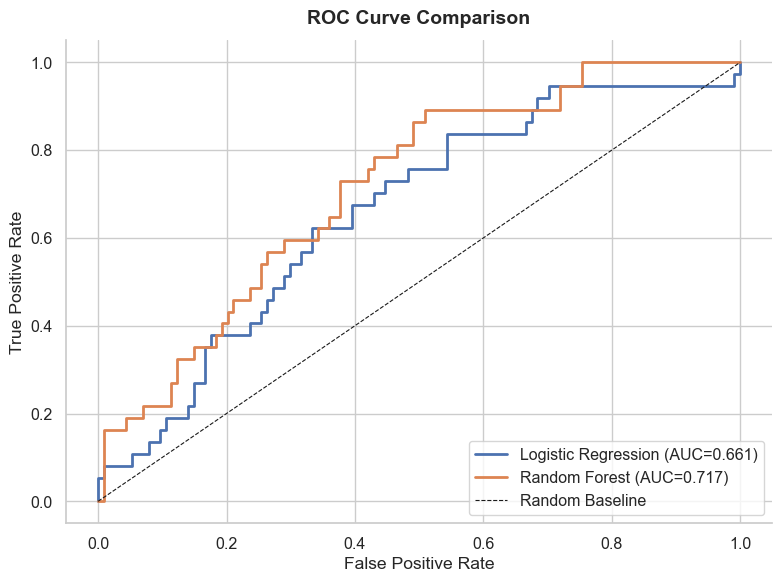

In [59]:
# ── Model Comparison: ROC Curves ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

ax.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC={lr_auc:.3f})', linewidth=2)
ax.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={rf_auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Baseline')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

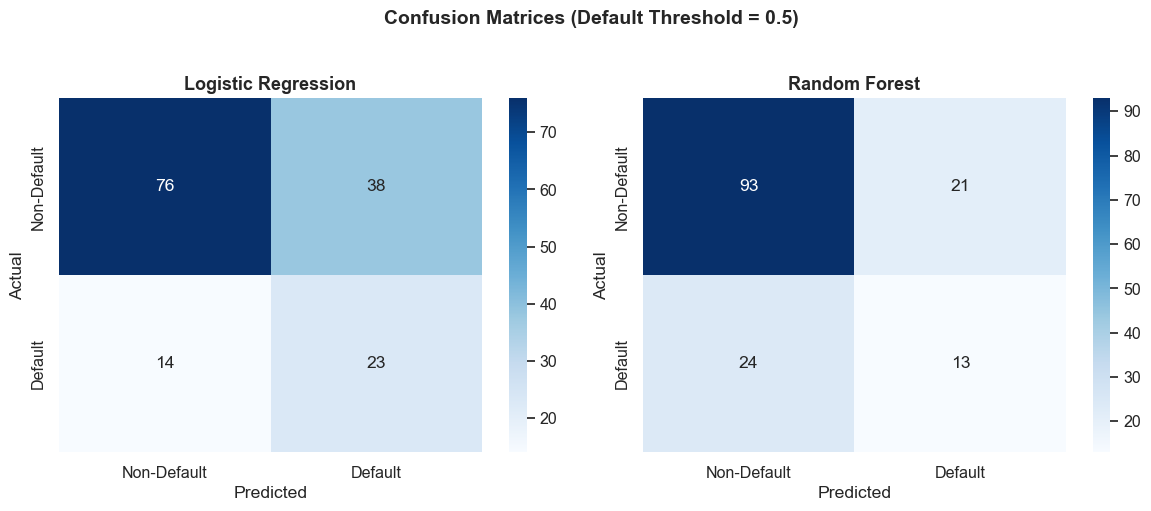

In [60]:
# ── Confusion Matrix Heatmaps ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in [(axes[0], lr_pred, 'Logistic Regression'),
                          (axes[1], rf_pred, 'Random Forest')]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices (Default Threshold = 0.5)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

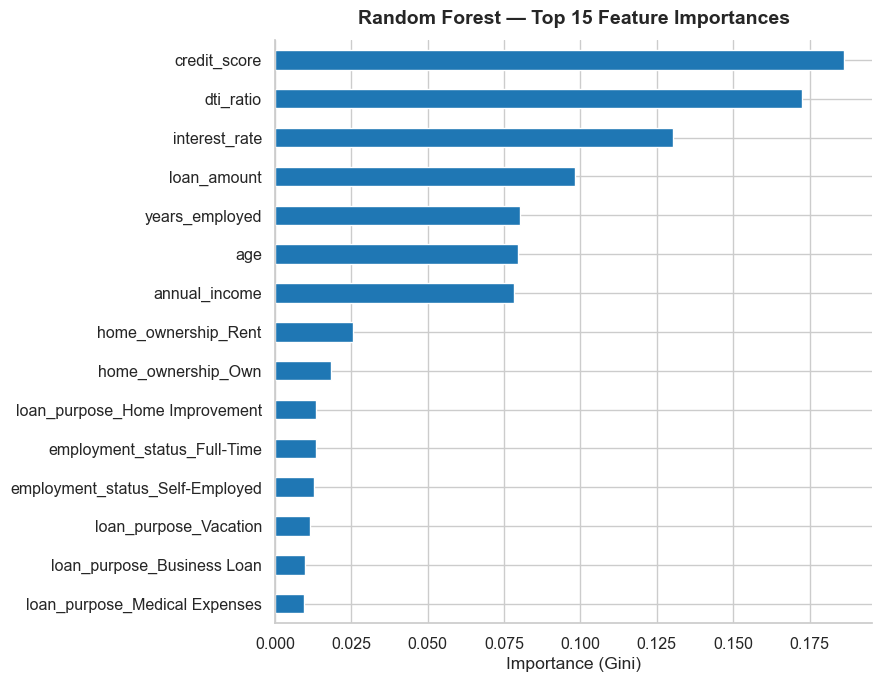

In [61]:
# ── Random Forest Feature Importance ─────────────────────────────────
rf_feature_names = numeric_features + list(
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

rf_importance = pd.Series(
    rf_pipeline.named_steps['classifier'].feature_importances_,
    index=rf_feature_names
).sort_values(ascending=True)

# Plot top 15 features
fig, ax = plt.subplots(figsize=(9, 7))
rf_importance.tail(15).plot.barh(ax=ax, color=COLOR_SAFE, edgecolor='white')
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance (Gini)')
sns.despine()
plt.tight_layout()
plt.show()

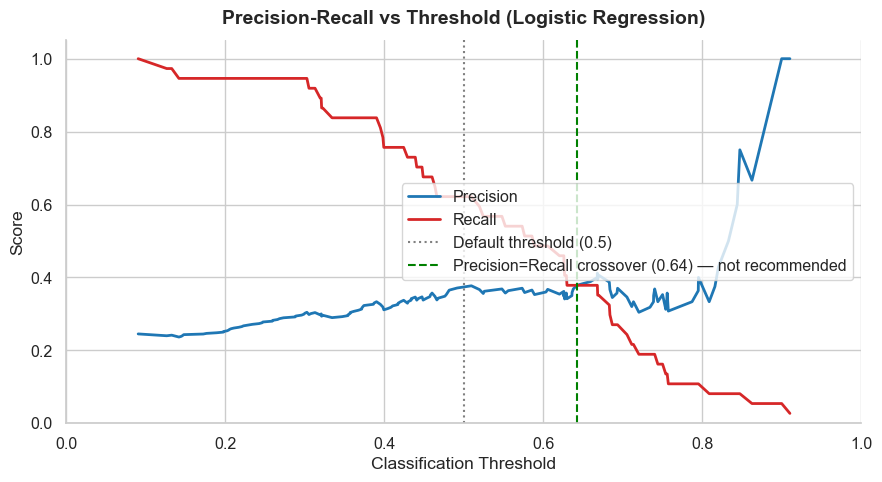

Default threshold (0.5): Precision=0.38, Recall=0.62
Crossover threshold (0.64): Precision=0.38, Recall=0.38


In [62]:
# ── Threshold Tuning (Precision-Recall Trade-off) ────────────────────
# The default 0.5 threshold is arbitrary. In credit risk, we may want
# higher recall (catch more defaults) even at the cost of precision.

precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, lr_probs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_lr, precision_lr[:-1], label='Precision', linewidth=2, color=COLOR_SAFE)
ax.plot(thresholds_lr, recall_lr[:-1], label='Recall', linewidth=2, color=COLOR_DEFAULT)
ax.axvline(x=0.5, color='gray', linestyle=':', label='Default threshold (0.5)')

# Find threshold where precision ≈ recall (crossover point)
diff = np.abs(precision_lr[:-1] - recall_lr[:-1])
balanced_idx = np.argmin(diff)
balanced_thresh = thresholds_lr[balanced_idx]
ax.axvline(x=balanced_thresh, color='green', linestyle='--',
           label=f'Precision=Recall crossover ({balanced_thresh:.2f}) — not recommended')

ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall vs Threshold (Logistic Regression)',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='center right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Default threshold (0.5): Precision={precision_lr[np.searchsorted(thresholds_lr, 0.5)]:.2f}, "
      f"Recall={recall_lr[np.searchsorted(thresholds_lr, 0.5)]:.2f}")
print(f"Crossover threshold ({balanced_thresh:.2f}): "
      f"Precision={precision_lr[balanced_idx]:.2f}, Recall={recall_lr[balanced_idx]:.2f}")

### Model Comparison Summary

| Metric | Logistic Regression | Random Forest |
|--------|-------------------:|-------------:|
| ROC-AUC (holdout) | 0.661 | **0.717** |
| Mean CV AUC | 0.679 ± 0.027 | 0.697 ± 0.057 |
| Recall (defaults) | **62%** | 35% |
| Precision (defaults) | 38% | 38% |

**Model choice depends on business objective:**
- If the goal is *ranking* borrowers by risk (scorecard use case), **RF is better** (AUC 0.717 vs 0.661)
- If the goal is *catching defaults* at a binary approve/decline threshold, **LR is better** (recall 62% vs 35%)
- LR is more **stable** across folds (std 0.027 vs 0.057)

**Note on removing `education_level`:** Dropping this non-significant feature (Step 7.8,
p = 0.44) improved LR holdout AUC from 0.636 to 0.661 and recall from 57% to 62%.
The top coefficients now align cleanly with EDA findings: `credit_score` (−0.77) and
`dti_ratio` (+0.51) dominate, with no reference category artifacts distorting the picture.

**Threshold tuning result:** The default 0.5 threshold outperforms the precision-recall
crossover point (0.64), where both metrics converge at 0.38. For this model, **0.5 is
a reasonable operating threshold.** In a production setting, the optimal threshold should
be calibrated against the actual cost ratio of a missed default vs a rejected good borrower.

**Next steps (separate project):** XGBoost with hyperparameter tuning, SHAP explanations
for individual predictions, and clustering-based borrower segmentation.

<a id="step14"></a>
# Step 14 — Conclusion

## Summary

This simulated portfolio's 24.3% default rate is driven primarily by two factors:
**low credit scores** and **high debt-to-income ratios**. The interaction heatmap shows
that borrowers with credit scores below 600 and DTI above 50% default at **60%**, five
times the scenario's target.

## Key Recommendations

1. **Credit score floor of 620** as an immediate hard cutoff — eliminates the two highest-risk buckets
2. **DTI cap of 55%** — the Standard policy (CS≥620, DTI≤55) achieves 12.3% default rate while preserving 50% of loan volume
3. **Auto-decline** any application where credit < 650 AND DTI > 50% (the toxic combination)
4. **Proactive Late loan intervention** — 103 loans at risk of tipping to default; if they convert, portfolio hits 41.4%
5. **Enhanced review** for DTI 45–55% range with senior underwriter approval

The Standard policy was identified as the optimal point on the trade-off curve: it achieves
essentially the same default rate as the Strict policy (12.3% vs 12.1%) while approving
71 more loans — a 31% volume advantage for 0.2pp of additional risk.

## Limitations

- **Small dataset** (601 loans) — statistical tests are significant but model
  performance has high variance across CV folds
- **No causal inference** — we identified associations, not causes
- **LGD assumption** — expected loss assumes 100% loss given default;
  actual recovery rates would reduce loss estimates
- **Late loan outcome unknown** — sensitivity analysis bounded the risk but
  we don't know the true conversion rate
- **Single time period** — 18 months of data; seasonal or economic cycle
  effects cannot be isolated

## Modeling Notes

Baseline models (Logistic Regression, Random Forest) confirmed EDA findings:
credit score and DTI are the dominant predictors. `education_level` was excluded
after a chi-square test found no significant relationship with default (p = 0.44);
removing it improved LR performance and eliminated misleading coefficients.

Model comparison showed a split decision — RF wins on AUC (0.717 vs 0.661) while
LR wins on recall (62% vs 35%) and stability (CV std 0.027 vs 0.057). For this
dataset size, LR's stability is the more trustworthy signal. The CV mean of 0.679
is the reliable performance estimate.

## Next Steps

This EDA forms the foundation for a dedicated **Loan Default Risk Intelligence System**
that will add:
- XGBoost with Bayesian hyperparameter tuning
- SHAP values for individual-level explanations ("why was THIS loan flagged?")
- Borrower clustering to discover natural risk segments
- Optimized probability thresholds calibrated to business cost functions

---
*Analysis completed using Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, and Scikit-learn.*